In [88]:
import pandas as pd
import matplotlib.pyplot as plt

In [89]:
processed = pd.read_csv("../../data/preprocessing/processed_data.csv")

def load_and_merge(file):
    df = pd.read_csv(file)
    df = df.merge(processed[['id', 'lat', 'lon']], on='id', how='left')
    return df

In [90]:
scenarios = [0, 1, 2, 3, 4]
reps = range(1, 11)

In [101]:
criticality_avg = {}

for s in scenarios:
    dfs = []
    for r in reps:
        file = f"scenario{s}_rep{r}_hotspots.csv"
        df = load_and_merge(file)
        df['rep'] = r
        dfs.append(df)

    df_all = pd.concat(dfs, ignore_index=True)

    df_avg = (
        df_all
        .groupby(['id', 'lat', 'lon'], as_index=False)['throughput']
        .mean()
    )

    criticality_avg[s] = df_avg

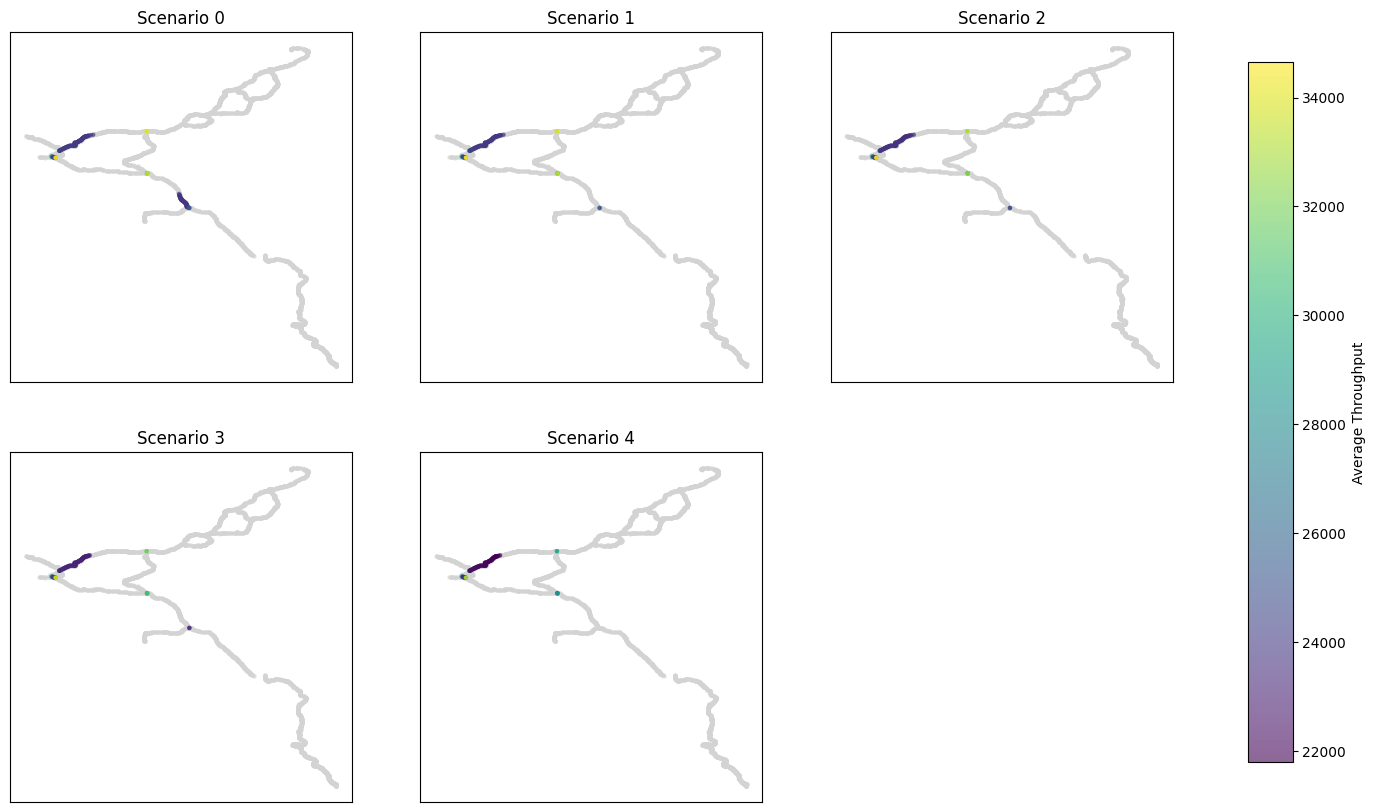

In [102]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
fig.delaxes(axes[5])
plot_axes = [axes[0], axes[1], axes[2], axes[3], axes[4]]

vmin = min(df['throughput'].min() for df in criticality_avg.values())
vmax = max(df['throughput'].max() for df in criticality_avg.values())

for i, s in enumerate(scenarios):
    ax = plot_axes[i]
    df = criticality_avg[s]

    ax.scatter(
        processed['lon'],
        processed['lat'],
        color='lightgrey',
        s=5,
        alpha=0.5,
        zorder=1
    )

    sc = ax.scatter(
        df['lon'],
        df['lat'],
        c=df['throughput'],
        s=5,
        alpha=0.6,
        vmin = vmin,
        vmax = vmax
    )

    ax.set_title(f"Scenario {s}")
    ax.set_xticks([])
    ax.set_yticks([])


cbar_ax = fig.add_axes([0.95, 0.15, 0.03, 0.7])  # [left, bottom, width, height]
cbar = fig.colorbar(sc, cax=cbar_ax)
cbar.set_label("Average Throughput")

plt.style.use('default')

plt.savefig("crit_heatmaps.png", dpi=600, bbox_inches='tight')

plt.show()

In [93]:
vulnerability_avg = {}

for s in scenarios:
    dfs = []
    for r in reps:
        file = f"scenario{s}_rep{r}_vulnerability.csv"
        df = load_and_merge(file)
        df['rep'] = r
        dfs.append(df)

    df_all = pd.concat(dfs, ignore_index=True)

    df_avg = (
        df_all
        .groupby(['id', 'lat', 'lon'], as_index=False)['total_delay_min']
        .mean()
    )

    vulnerability_avg[s] = df_avg

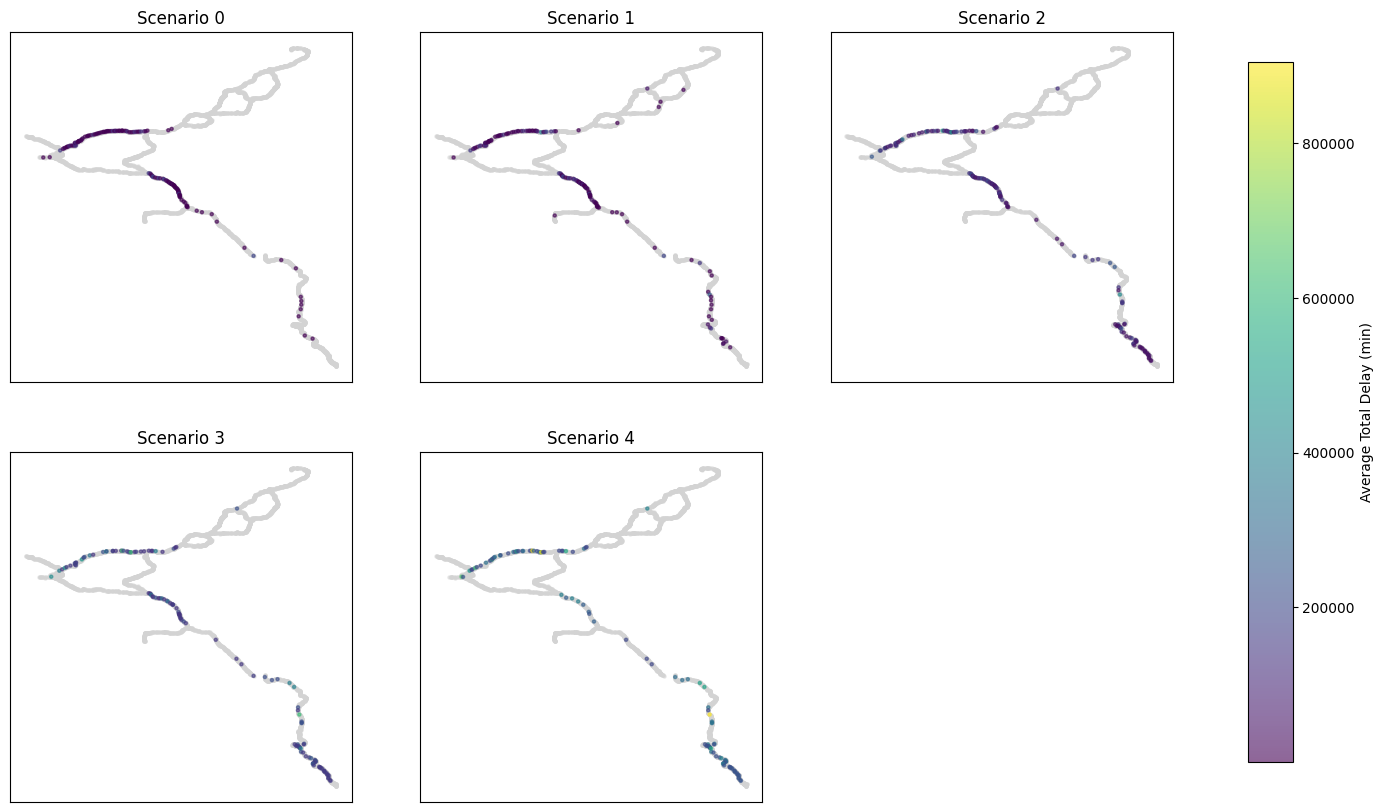

In [105]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
fig.delaxes(axes[5])
plot_axes = [axes[0], axes[1], axes[2], axes[3], axes[4]]

vmin = min(df['total_delay_min'].min() for df in vulnerability_avg.values())
vmax = max(df['total_delay_min'].max() for df in vulnerability_avg.values())

for i, s in enumerate(scenarios):
    ax = plot_axes[i]
    df = vulnerability_avg[s]

    ax.scatter(
        processed['lon'],
        processed['lat'],
        color='lightgrey',
        s=5,
        alpha=0.5,
        zorder=1
    )

    sc = ax.scatter(
        df['lon'],
        df['lat'],
        c=df['total_delay_min'],
        s=5,
        alpha=0.6,
        vmin=vmin,
        vmax=vmax
    )

    ax.set_title(f"Scenario {s}")
    ax.set_xticks([])
    ax.set_yticks([])


cbar_ax = fig.add_axes([0.95, 0.15, 0.03, 0.7])  # [left, bottom, width, height]
cbar = fig.colorbar(sc, cax=cbar_ax)
cbar.set_label("Average Total Delay (min)")

plt.style.use('default')

plt.savefig("vul_heatmaps.png", dpi=600, bbox_inches='tight')

plt.show()

In [106]:
# Combine all scenarios into a single DataFrame
all_scenarios = []
for s in scenarios:
    df = vulnerability_avg[s][['id', 'total_delay_min']].copy()
    df = df.rename(columns={'total_delay_min': f'scenario_{s}'})
    all_scenarios.append(df)

# Merge all scenarios on 'id'
merged = all_scenarios[0]
for df in all_scenarios[1:]:
    merged = merged.merge(df, on='id', how='outer')

# Fill missing delays with 0 (nodes not affected in some scenarios)
merged = merged.fillna(0)

# Compute average across all scenarios
merged['average_delay'] = merged[[f'scenario_{s}' for s in scenarios]].mean(axis=1)

# Get top 10 nodes by average delay
top10_overall = merged.sort_values('average_delay', ascending=False).head(10)['id'].values

# Now build the full table including top 10 per scenario and overall
top_ids = {}
for s in scenarios:
    df = vulnerability_avg[s]
    top_ids[f"Scenario {s}"] = df.sort_values('total_delay_min', ascending=False)['id'].head(10).values

top_ids['Average Top 10'] = top10_overall

# Convert to DataFrame
top_table = pd.DataFrame(top_ids)

print(top_table)

   Scenario 0  Scenario 1  Scenario 2  Scenario 3  Scenario 4  Average Top 10
0         565        1541        1518        1518         798            1541
1         279         798        1541        1541        1518             798
2         216         565         798         798        1541            1518
3         209        1553        1373        1373          16            1373
4         199         279        1422        1422        1373            1422
5        1363         209        1483        1483        1422            1483
6         188         199        1360          16        1483            1018
7        1393        1363         666        1018        1018              16
8        1561         188          16         666        1589             643
9        1501         216        1018        1589         666             666
